<div style="display: flex; align-items: center; justify-content: space-between">
    <div>
        <img src="https://raw.githubusercontent.com/sebastianVP/RADAR_AMISR/refs/heads/main/igp_logo.jpeg"
         alt="LOGO IGP" width="200" height="200" style="margin-left: 20px; border-radius: 10px;" align = "right">
        <h1 style="color: #800020;  font-weight: bold; margin-bottom: 10px; font-family: Arial, sans-serif;">
          <font color="#7F000E">
            Maestría de Ciencias de la Computación UNI-IGP
          </font>
        </h1>
        <h2 style="color: #800020;font-weight: bold; max-width: 750px; font-family: Arial, sans-serif;">
          <strong><font color="#7F000E" size=5 >
            Desarrollo de sistema de pronóstico de centelleo ionosférico sobre el Perú para alerta de
            perturbaciones en señales satelitales
          </font ></strong>
        </h2>
    </div>
</div>
<div>
    <p style="margin-bottom: 5px;">
    <strong>
    <font color="#7F000E" size=3 > N1-MODULO DE PROCESAMIENTO PARA CINTILACIONES IONOFÉRICAS </strong></p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Alumno:</strong></font>
    <font color="#7F000E"> Alexander Valdez Portocarrero</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Código:</strong> 20207072E</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Fecha:</strong>  26/11/2025</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong> Ciclo 2025-2</strong></p>
</div>

---

In [77]:
# =============================================================================
# MODULO DE PREPROCESAMIENTO PARA CINTILACIONES IONOSFÉRICAS
# Autor: Alexander Valdez Portocarrero
# Descripción: Carga, análisis exploratorio y preparación de tensores para LSTM
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf # Solo si necesitas verificar GPU aquí
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Importaciones específicas de Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# =============================================================================
# 1. CARGA DE DATOS
# =============================================================================
def cargar_dataset(path, filename):
    """
    Carga el CSV y realiza la conversión inicial de fechas.
    """
    full_path = os.path.join(path, filename)
    
    if not os.path.exists(full_path):
        raise FileNotFoundError(f"No se encontró el archivo en: {full_path}")
    
    print(f"📂 Cargando archivo: {filename}...")
    df = pd.read_csv(full_path)
    
    # Conversión única y definitiva a datetime
    df["Tiempo"] = pd.to_datetime(df["Tiempo"])
    
    # Ordenar cronológicamente (vital para series temporales)
    df = df.sort_values("Tiempo")
    
    print(f"✅ Dataset cargado. Shape: {df.shape}")
    print(f"   Rango de fechas: {df['Tiempo'].min()} a {df['Tiempo'].max()}")
    return df

# =============================================================================
# 2. ANÁLISIS EXPLORATORIO (EDA)
# =============================================================================
def analizar_eventos_cintilacion(df, umbral_s4=0.6, plot=True):
    """
    Analiza y visualiza los días con presencia de cintilación.
    No modifica el DF original permanentemente, solo reporta estadísticas.
    """
    print("\n🔍 Analizando distribución de eventos...")
    
    # Trabajamos con una copia ligera para no alterar el original
    df_analisis = df[["Tiempo", "S4"]].copy()
    df_analisis["Fecha"] = df_analisis["Tiempo"].dt.date
    
    # 1. Identificar si cada día superó el umbral
    resumen_diario = df_analisis.groupby("Fecha")["S4"].max() > umbral_s4
    resumen_diario = resumen_diario.reset_index()
    resumen_diario.columns = ["Fecha", "Evento_Cintilacion"] # True/False
    
    total_dias = resumen_diario["Fecha"].nunique()
    dias_con_evento = resumen_diario["Evento_Cintilacion"].sum()
    
    print(f"   Total de días registrados: {total_dias}")
    print(f"   Días con eventos (S4 > {umbral_s4}): {dias_con_evento}")
    print(f"   Porcentaje de actividad: {(dias_con_evento/total_dias)*100:.2f}%")
    
    # 2. Reporte Mensual
    df_analisis["Mes"] = df_analisis["Tiempo"].dt.to_period("M")
    
    # Unimos para saber qué día tuvo evento
    # Primero agrupamos por día para saber si ESE día hubo evento
    max_s4_dia = df_analisis.groupby(["Mes", "Fecha"])["S4"].max().reset_index()
    max_s4_dia["Tuvo_Evento"] = (max_s4_dia["S4"] > umbral_s4).astype(int)
    
    # Tabla resumen
    tabla_mensual = max_s4_dia.groupby("Mes")["Tuvo_Evento"].agg(
        Dias_Con_Cintilacion='sum',
        Total_Dias='count'
    )
    tabla_mensual["Dias_Sin_Cintilacion"] = tabla_mensual["Total_Dias"] - tabla_mensual["Dias_Con_Cintilacion"]
    
    print("\n📊 Resumen Mensual de Actividad:")
    print(tabla_mensual)

    # 3. Visualización (Opcional)
    if plot:
        plt.figure(figsize=(12, 5))
        # Convertimos a string para que matplotlib no haga lío con fechas
        fechas_str = resumen_diario["Fecha"].astype(str)
        valores = resumen_diario["Evento_Cintilacion"].astype(int)
        
        plt.bar(fechas_str, valores, color=np.where(valores==1, 'orange', 'skyblue'))
        plt.title(f"Días con Cintilación (S4 > {umbral_s4})")
        plt.ylabel("Presencia (1=Sí, 0=No)")
        plt.xticks(rotation=90, fontsize=8)
        
        # Mostrar solo una etiqueta cada 7 días para no saturar
        ax = plt.gca()
        for index, label in enumerate(ax.xaxis.get_ticklabels()):
            if index % 7 != 0:
                label.set_visible(False)
                
        plt.tight_layout()
        plt.show()

# =============================================================================
# 3. INGENIERÍA DE CARACTERÍSTICAS (FEATURE ENGINEERING)
# =============================================================================
def agregar_caracteristicas_temporales(df):
    """
    Agrega transformaciones cíclicas de tiempo (Seno/Coseno).
    """
    print("\n⚙️ Generando características temporales (Sin/Cos)...")
    
    # Calcular minuto del día (0–1439)
    minutos_dia = df["Tiempo"].dt.hour * 60 + df["Tiempo"].dt.minute
    periodo = 24 * 60 # 1440 minutos
    
    # Transformación
    df["Hora_Sin"] = np.sin(2 * np.pi * minutos_dia / periodo)
    df["Hora_Cos"] = np.cos(2 * np.pi * minutos_dia / periodo)
    
    return df

# =============================================================================
# 4. PREPARACIÓN FINAL DE ESTRUCTURA
# =============================================================================
def finalizar_estructura_df(df, target_col="S4"):
    """
    Limpia columnas auxiliares, reordena y establece el índice temporal.
    Esta función deja el DF listo para entrar al Generador de Ventanas.
    """
    print("\n🧹 Finalizando estructura del DataFrame...")
    
    # 1. Asegurar índice temporal
    if df.index.name != 'Tiempo':
        df = df.set_index('Tiempo')
    
    df = df.sort_index()
    
    # 2. Reordenar columnas: Target al final (práctica estándar)
    cols = [c for c in df.columns if c != target_col]
    cols.append(target_col)
    df = df[cols]
    
    # 3. Eliminar columnas que ya no sirven para el modelo numérico
    # (Ej: Fechas string, columnas categóricas, etc.)
    cols_a_borrar = ["dias", "Fecha", "Mes", "minuto_del_dia", "Cintilacion"]
    # Borramos solo si existen
    cols_existentes = [c for c in cols_a_borrar if c in df.columns]
    
    if cols_existentes:
        df = df.drop(columns=cols_existentes)
        print(f"   Columnas eliminadas: {cols_existentes}")
        
    print(f"✅ DataFrame Final Listo. Shape: {df.shape}")
    print(f"   Columnas finales: {df.columns.tolist()}")
    
    return df

# =============================================================================
# 5. ESTRATEGIA DE DIVISIÓN DE DATOS (DATA SPLITTING)
# =============================================================================
def dividir_estratificado_por_dias(df, umbral_s4=0.6):
    """
    Divide el dataset asegurando que haya días con tormentas en Train, Val y Test.
    """
    print("\n✂️ Ejecutando división estratificada de datos...")
    
    # Trabajamos con copia para no afectar el original
    temp_df = df.copy()
    
    # Si la columna Fecha no existe (porque la borramos en el paso 4), la recuperamos del índice
    if 'Fecha' not in temp_df.columns:
        temp_df['Fecha'] = temp_df.index.date
    
    # 1. Identificar Días Activos vs Días Quietos
    resumen_diario = temp_df.groupby('Fecha')['S4'].max().reset_index()
    
    dias_activos = resumen_diario[resumen_diario['S4'] > umbral_s4]['Fecha'].values
    dias_quietos = resumen_diario[resumen_diario['S4'] <= umbral_s4]['Fecha'].values
    
    print(f"   Total Días Activos encontrados: {len(dias_activos)}")
    print(f"   Total Días Quietos encontrados: {len(dias_quietos)}")
    
    # 2. Repartir los Días ACTIVOS (aprox 70/15/15)
    # Primero separamos Train (70%) del resto (30%)
    activos_train, activos_temp = train_test_split(dias_activos, test_size=0.3, random_state=42)
    # Luego separamos ese resto en Val (50% del resto) y Test (50% del resto)
    activos_val, activos_test = train_test_split(activos_temp, test_size=0.5, random_state=42)
    
    # 3. Repartir los Días QUIETOS (misma lógica)
    quietos_train, quietos_temp = train_test_split(dias_quietos, test_size=0.3, random_state=42)
    quietos_val, quietos_test = train_test_split(quietos_temp, test_size=0.5, random_state=42)
    
    # 4. Combinar las listas
    lista_dias_train = np.concatenate([activos_train, quietos_train])
    lista_dias_val = np.concatenate([activos_val, quietos_val])
    lista_dias_test = np.concatenate([activos_test, quietos_test])
    
    # 5. Crear los DataFrames Finales
    # Ordenamos por fecha para mantener la lógica temporal interna
    # NOTA: Usamos temp_df['Fecha'] para filtrar, pero devolvemos df (el original limpio)
    #       Para asegurar consistencia, filtramos temp_df y luego dropeamos 'Fecha' si fue agregada,
    #       o simplemente usamos el índice.
    
    # Filtrar usando las fechas
    train = temp_df[temp_df['Fecha'].isin(lista_dias_train)].sort_index()
    val = temp_df[temp_df['Fecha'].isin(lista_dias_val)].sort_index()
    test = temp_df[temp_df['Fecha'].isin(lista_dias_test)].sort_index()
    
    # Limpieza final: Si agregamos 'Fecha' temporalmente, la quitamos para dejar los datos limpios
    if 'Fecha' in train.columns:
        train = train.drop(columns=['Fecha'])
        val = val.drop(columns=['Fecha'])
        test = test.drop(columns=['Fecha'])
    
    return train, val, test

def auditar_division_datos(df, nombre_set, umbral_s4=0.6):
    """
    Función auxiliar para verificar que cada set tenga eventos.
    """
    # Recuperamos fecha del índice para el análisis
    fechas = df.index.date
    s4_values = df['S4'].values
    
    # Dataframe temporal para agrupar
    df_temp = pd.DataFrame({'Fecha': fechas, 'S4': s4_values})
    
    # Contar
    dias_totales = df_temp['Fecha'].nunique()
    dias_con_evento = df_temp[df_temp['S4'] > umbral_s4]['Fecha'].nunique()
    
    porcentaje = 0
    if dias_totales > 0:
        porcentaje = (dias_con_evento / dias_totales) * 100
        
    print(f"--- AUDITORÍA: {nombre_set.upper()} ---")
    print(f"📅 Días totales: {dias_totales}")
    print(f"⚡ Días con Cintilación: {dias_con_evento}")
    print(f"📊 Porcentaje actividad: {porcentaje:.2f}%")
    
    if dias_con_evento == 0:
        print(f"⚠️ PELIGRO: {nombre_set} NO tiene eventos. El modelo fallará aquí.")
    else:
        print("✅ Set válido.")
    print("-" * 30)

# =============================================================================
# 6. NORMALIZACIÓN DE DATOS (SCALING)
# =============================================================================
def escalar_preservando_indices(df_subset, scaler, cols, is_train=False):
    """
    Normaliza un DataFrame pero devuelve otro DataFrame con el mismo índice temporal.
    """
    if df_subset.empty: 
        return df_subset
    
    # IMPORTANTE: Solo 'aprendemos' (fit) los máximos y mínimos con el set de TRAIN
    if is_train:
        scaler.fit(df_subset[cols])
    
    # Transformamos los datos (Matriz numpy)
    scaled_values = scaler.transform(df_subset[cols])
    
    # Reconstruimos el DataFrame pegándole el índice original
    df_scaled = pd.DataFrame(
        scaled_values, 
        columns=cols, 
        index=df_subset.index 
    )
    
    # Añadimos la columna 'Fecha' para referencia (útil para depuración)
    # Si la columna no existe en el subset, la extraemos del índice
    if 'Fecha' in df_subset.columns:
        df_scaled['Fecha'] = df_subset['Fecha'].values
    else:
        df_scaled['Fecha'] = df_subset.index.date
    
    return df_scaled

def normalizar_sets(train_df, val_df, test_df, features_cols):
    """
    Aplica la normalización a los tres conjuntos de datos usando MinMaxScaler.
    """
    print("\n⚖️ Ejecutando Normalización (MinMaxScaler 0-1)...")
    
    # Inicializamos el escalador
    scaler = MinMaxScaler(feature_range=(0, 1))
    
    # 1. Normalizamos TRAIN (Aquí aprende el scaler)
    print("   -> Normalizando Train (Fit & Transform)")
    train_scaled = escalar_preservando_indices(train_df, scaler, features_cols, is_train=True)
    
    # 2. Normalizamos VAL y TEST (Usando lo aprendido en Train)
    print("   -> Normalizando Val (Transform only)")
    val_scaled = escalar_preservando_indices(val_df, scaler, features_cols, is_train=False)
    
    print("   -> Normalizando Test (Transform only)")
    test_scaled = escalar_preservando_indices(test_df, scaler, features_cols, is_train=False)
    
    # Verificación
    s4_min_orig = train_df['S4'].min()
    s4_max_orig = train_df['S4'].max()
    s4_min_scal = train_scaled['S4'].min()
    s4_max_scal = train_scaled['S4'].max()
    
    print(f"   ✅ Normalización completada.")
    print(f"   Rango S4 Original (Train): {s4_min_orig:.4f} a {s4_max_orig:.4f}")
    print(f"   Rango S4 Escalado (Train): {s4_min_scal:.4f} a {s4_max_scal:.4f}")
    
    return train_scaled, val_scaled, test_scaled, scaler


# =============================================================================
# 7. GENERACIÓN DE VENTANAS (SLIDING WINDOWS)
# =============================================================================
def crear_dataset_lstm_con_gaps(df, cols_input, col_target, lookback=60, horizon=20):
    """
    Genera tensores X e y verificando rigurosamente la continuidad del tiempo.
    """
    # 1. Preparación de datos crudos para velocidad
    data_values = df[cols_input].values  
    target_values = df[col_target].values
    
    # Extraemos los tiempos para poder hacer las restas
    timestamps = df.index.to_series().values
    
    X, y = [], []
    
    # 2. Bucle Principal (El "Deslizamiento")
    for i in range(lookback, len(df) - horizon):
        
        # --- EL VIGILANTE DE TIEMPO (GAP CONTROL) ---
        t_actual = timestamps[i]                 # El "Ahora" (t)
        t_inicio = timestamps[i - lookback]      # El inicio de la ventana (t - 60)
        t_futuro = timestamps[i + horizon]       # El objetivo (t + 20)
        
        # Calculamos diferencias en MINUTOS
        diff_atras = (t_actual - t_inicio) / np.timedelta64(1, 'm')
        diff_adelante = (t_futuro - t_actual) / np.timedelta64(1, 'm')
        
        # CONDICIÓN 1: Continuidad Ventana de entrada
        if diff_atras != lookback:
            continue 
            
        # CONDICIÓN 2: Existencia del Futuro exacto
        if diff_adelante != horizon:
            continue 
            
        # --- SI PASA LAS PRUEBAS, GUARDAMOS ---
        ventana = data_values[i-lookback : i] 
        objetivo = target_values[i + horizon]
        
        X.append(ventana)
        y.append(objetivo)

    return np.array(X), np.array(y)

def generar_tensores(train_scaled, val_scaled, test_scaled, features_cols, target_col='S4', lookback=60, horizon=20):
    """
    Función orquestadora para generar los tensores de Train, Val y Test.
    """
    print(f"\n🎞️ Generando Ventanas Deslizantes (Lookback={lookback}, Horizon={horizon})...")
    print(f"   Features ({len(features_cols)}): {features_cols}")
    
    # 1. Train
    X_train, y_train = crear_dataset_lstm_con_gaps(train_scaled, features_cols, target_col, lookback, horizon)
    print(f"   ✅ TRAIN generado. Muestras válidas: {X_train.shape[0]}")
    
    # 2. Val
    X_val, y_val = crear_dataset_lstm_con_gaps(val_scaled, features_cols, target_col, lookback, horizon)
    print(f"   ✅ VAL generado.   Muestras válidas: {X_val.shape[0]}")
    
    # 3. Test
    X_test, y_test = crear_dataset_lstm_con_gaps(test_scaled, features_cols, target_col, lookback, horizon)
    print(f"   ✅ TEST generado.  Muestras válidas: {X_test.shape[0]}")
    
    # Verificación
    print("\n--- DIMENSIONES FINALES (Tensor Shapes) ---")
    print(f"   X_train: {X_train.shape}")
    print(f"   y_train: {y_train.shape}")
    
    return X_train, y_train, X_val, y_val, X_test, y_test

# =============================================================================
# 8. MODELADO (LSTM)
# =============================================================================
def calcular_umbral_normalizado(scaler, features_cols, umbral_real=0.6, col_target='S4'):
    """
    Calcula el equivalente de 0.6 S4 en la escala 0-1.
    """
    idx_target = features_cols.index(col_target)
    
    # Recuperamos metadatos del scaler
    val_min = scaler.data_min_[idx_target]
    val_max = scaler.data_max_[idx_target]
    
    # Fórmula MinMax: (x - min) / (max - min)
    umbral_norm = (umbral_real - val_min) / (val_max - val_min)
    
    print(f"\n📏 Cálculo de Umbral Normalizado:")
    print(f"   S4 Real: {umbral_real}  =>  S4 Norm: {umbral_norm:.4f}")
    
    return umbral_norm

def weighted_mse(threshold, penalty_weight):
    """
    Función de pérdida ponderada para penalizar errores en valores altos.
    """
    def loss(y_true, y_pred):
        squared_error = tf.keras.backend.square(y_pred - y_true)
        weights = tf.where(y_true >= threshold, penalty_weight, 1.0)
        return tf.keras.backend.mean(squared_error * weights, axis=-1)
    return loss

def construir_modelo_lstm(input_shape, umbral_norm, penalty=15.0):
    """
    Define y compila la arquitectura LSTM.
    """
    tf.keras.backend.clear_session()
    
    model = Sequential()
    
    # Capa de Entrada
    model.add(Input(shape=input_shape))
    
    # Capa LSTM
    model.add(LSTM(64, activation='tanh', return_sequences=False))
    
    # Regularización
    model.add(Dropout(0.2))
    
    # Interpretación
    model.add(Dense(32, activation='relu'))
    
    # Salida (Lineal)
    model.add(Dense(1, activation='linear'))
    
    # Compilación con Loss Ponderada
    loss_fn = weighted_mse(threshold=umbral_norm, penalty_weight=penalty)
    
    model.compile(
        optimizer='adam',
        loss=loss_fn,
        metrics=['mae']
    )
    
    print("\n🧠 Modelo LSTM Compilado:")
    model.summary()
    return model

def entrenar_modelo(model, X_train, y_train, X_val, y_val, batch_size=32, epochs=100):
    """
    Ejecuta el entrenamiento con EarlyStopping.
    """
    callbacks = [
        EarlyStopping(
            monitor='val_loss', 
            patience=10, 
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            filepath='modelo_s4_lstm_mejor.keras',
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        )
    ]
    
    print("\n🚀 Iniciando entrenamiento...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )
    return history, model


# =============================================================================
# 9. PREDICCIÓN Y DESNORMALIZACIÓN
# =============================================================================
def desnormalizar_valor(data_scaled, scaler, features_cols, col_target='S4'):
    """
    Des-normaliza una columna específica usando los parámetros del scaler ajustado.
    Fórmula: Real = Scaled * (Max - Min) + Min
    """
    # Identificar índice de la columna objetivo
    idx = features_cols.index(col_target)
    
    # Recuperar min y max aprendidos
    val_min = scaler.data_min_[idx]
    val_max = scaler.data_max_[idx]
    val_range = val_max - val_min
    
    # Aplicar fórmula inversa
    data_real = (data_scaled * val_range) + val_min
    
    return data_real

def evaluar_predicciones(model, X_test, y_test, scaler, features_cols, col_target='S4'):
    """
    Genera predicciones y las convierte a escala real para evaluación.
    """
    print("\n🔮 Generando predicciones sobre el Test Set...")
    
    # 1. Predecir (Escala 0-1)
    y_pred_scaled = model.predict(X_test)
    
    # Asegurar dimensiones (N, 1)
    y_test_scaled = y_test.reshape(-1, 1)
    
    # 2. Des-normalizar
    y_pred_real = desnormalizar_valor(y_pred_scaled, scaler, features_cols, col_target)
    y_test_real = desnormalizar_valor(y_test_scaled, scaler, features_cols, col_target)
    
    print("✅ Datos convertidos a escala real.")
    print(f"   Ejemplo Real vs Predicción: {y_test_real[0][0]:.3f} vs {y_pred_real[0][0]:.3f}")
    
    return y_pred_real, y_test_real

# =============================================================================
# 10. EVALUACIÓN Y VISUALIZACIÓN
# =============================================================================
def evaluar_rendimiento(y_true, y_pred, umbral_evento=0.6):
    """
    Calcula métricas de error global y específicas para eventos de tormenta.
    """
    # 1. Error Global
    rmse_global = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_global = mean_absolute_error(y_true, y_pred)
    
    # 2. Error solo en Eventos (Donde realmente había cintilación)
    mask_eventos = y_true >= umbral_evento
    
    # Aplanamos para asegurar que numpy pueda indexar correctamente
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()
    mask_eventos_flat = mask_eventos.flatten()
    
    if np.sum(mask_eventos_flat) > 0:
        rmse_eventos = np.sqrt(mean_squared_error(y_true_flat[mask_eventos_flat], y_pred_flat[mask_eventos_flat]))
        mae_eventos = mean_absolute_error(y_true_flat[mask_eventos_flat], y_pred_flat[mask_eventos_flat])
    else:
        rmse_eventos = 0
        mae_eventos = 0
        print("⚠️ No se encontraron eventos > 0.6 en este set de datos.")

    print(f"\n--- REPORTE DE RENDIMIENTO ---")
    print(f"Global RMSE: {rmse_global:.4f}")
    print(f"Global MAE:  {mae_global:.4f}")
    print(f"-"*30)
    print(f"⚡ ERROR EN TORMENTAS (S4 > {umbral_evento}):")
    print(f"Event RMSE:  {rmse_eventos:.4f}")
    print(f"Event MAE:   {mae_eventos:.4f}")
    
    return rmse_global, rmse_eventos

def graficar_escenario(y_true, y_pred, inicio, fin, titulo="Comparación"):
    """
    Grafica una ventana específica de tiempo comparando Real vs Predicho.
    """
    plt.figure(figsize=(14, 6))
    
    # Aseguramos límites
    start = max(0, int(inicio))
    end = min(len(y_true), int(fin))
    
    # Graficamos Real vs Predicho
    plt.plot(y_true[start:end], label='S4 Real (Observado)', color='black', linewidth=1.5)
    plt.plot(y_pred[start:end], label='S4 Predicho (LSTM)', color='red', linestyle='--', linewidth=1.5)
    
    # Línea de umbral de cintilación
    plt.axhline(y=0.6, color='orange', linestyle=':', label='Umbral S4 > 0.6')
    
    plt.title(titulo)
    plt.ylabel('Índice S4')
    plt.xlabel('Pasos de Tiempo (Minutos en la ventana)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def visualizar_resultados_finales(y_true, y_pred):
    """
    Orquesta la visualización de los escenarios clave.
    """
    # 1. Escenario General (Primeras 1000 muestras o total si es menor)
    limit_general = min(1000, len(y_true))
    graficar_escenario(y_true, y_pred, 0, limit_general, "Escenario 1: Visión General (Primeras horas)")
    
    # 2. Escenario Tormenta (Zoom automático al pico máximo)
    # Buscamos dónde ocurre la peor tormenta en el set de prueba
    idx_max_s4 = np.argmax(y_true)
    val_max = y_true[idx_max_s4]
    
    print(f"\n🔎 Buscando la tormenta más fuerte... Pico detectado: {val_max} en índice {idx_max_s4}")
    
    start_zoom = max(0, idx_max_s4 - 200) # 200 mins antes del pico
    end_zoom = min(len(y_true), idx_max_s4 + 200) # 200 mins después
    
    graficar_escenario(y_true, y_pred, start_zoom, end_zoom, "Escenario 2: ZOOM en la Tormenta Principal")

def calcular_metricas(y_true, y_pred, umbral_evento=0.6):
    """
    Calcula métricas y retorna un diccionario.
    """
    # 1. Error Global
    rmse_global = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_global = mean_absolute_error(y_true, y_pred)
    
    # 2. Error solo en Eventos
    mask_eventos = y_true >= umbral_evento
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()
    mask_eventos_flat = mask_eventos.flatten()
    
    if np.sum(mask_eventos_flat) > 0:
        rmse_eventos = np.sqrt(mean_squared_error(y_true_flat[mask_eventos_flat], y_pred_flat[mask_eventos_flat]))
        mae_eventos = mean_absolute_error(y_true_flat[mask_eventos_flat], y_pred_flat[mask_eventos_flat])
    else:
        rmse_eventos = 0
        mae_eventos = 0

    return {
        "Global_RMSE": rmse_global,
        "Global_MAE": mae_global,
        "Event_RMSE": rmse_eventos,
        "Event_MAE": mae_eventos
    }

# =============================================================================
# 11. GESTIÓN DE EXPERIMENTOS (NUEVO)
# =============================================================================
def ejecutar_experimento_iterativo(train_s, val_s, test_s, features_cols, scaler, lookbacks, horizons):
    """
    Ejecuta un Grid Search sobre combinaciones de Lookback y Horizon.
    """
    resultados = []
    total_iteraciones = len(lookbacks) * len(horizons)
    iter_actual = 0
    
    print(f"\n🧪 INICIANDO EXPERIMENTO ITERATIVO ({total_iteraciones} Combinaciones)...")
    print(f"   Lookbacks: {lookbacks}")
    print(f"   Horizons:  {horizons}")
    print("="*60)
    
    # Umbral constante para todo el experimento
    umbral_norm = calcular_umbral_normalizado(scaler, features_cols, umbral_real=0.6)

    for lb in lookbacks:
        for hz in horizons:
            iter_actual += 1
            print(f"\n🔄 [{iter_actual}/{total_iteraciones}] Probando: Lookback={lb} min, Horizon={hz} min")
            
            # 1. Generar Tensores Específicos
            X_train, y_train, X_val, y_val, X_test, y_test = generar_tensores(
                train_s, val_s, test_s, features_cols, 
                target_col='S4', lookback=lb, horizon=hz
            )
            
            if X_train.shape[0] == 0:
                print("   ⚠️ Salto: No hay suficientes datos para esta ventana.")
                continue

            # 2. Construir Modelo Nuevo
            input_shape = (X_train.shape[1], X_train.shape[2])
            model = construir_modelo_lstm(input_shape, umbral_norm, penalty=30.0)
            
            # 3. Entrenar
            history, _ = entrenar_modelo(
                model, 
                X_train.astype('float32'), y_train.astype('float32'), 
                X_val.astype('float32'), y_val.astype('float32'), 
                batch_size=64, epochs=60 # Menos épocas para iterar rápido
            )
            
            # 4. Evaluar
            y_pred, y_real = evaluar_predicciones(model, X_test, y_test, scaler, features_cols)
            metricas = calcular_metricas(y_real, y_pred, umbral_evento=0.6)
            
            # 5. Guardar Resultados
            registro = {
                "Lookback": lb,
                "Horizon": hz,
                **metricas
            }
            resultados.append(registro)
            
            print(f"   📊 Resultado: Event RMSE={metricas['Event_RMSE']:.4f} | Global RMSE={metricas['Global_RMSE']:.4f}")

    return pd.DataFrame(resultados)

def visualizar_resultados_experimento(df_resultados):
    """
    Genera tabla y gráficos comparativos.
    """
    print("\n\n🏆 TABLA FINAL DE RESULTADOS ORDENADA POR ERROR EN EVENTOS:")
    df_sorted = df_resultados.sort_values("Event_RMSE")
    print(df_sorted.to_string(index=False))
    
    # Gráfico
    plt.figure(figsize=(14, 6))
    
    # Crear etiquetas para el eje X
    labels = [f"L={row.Lookback}/H={row.Horizon}" for idx, row in df_resultados.iterrows()]
    x = np.arange(len(labels))
    width = 0.35
    
    plt.bar(x - width/2, df_resultados["Event_RMSE"], width, label='Error en Tormentas (RMSE)', color='salmon')
    plt.bar(x + width/2, df_resultados["Global_RMSE"], width, label='Error Global (RMSE)', color='skyblue')
    
    plt.xlabel('Configuración (Lookback / Horizon)')
    plt.ylabel('RMSE (Menor es mejor)')
    plt.title('Comparación de Rendimiento por Configuración Temporal')
    plt.xticks(x, labels, rotation=45)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()



# **PRUEBA INICIAL**

📂 Cargando archivo: df_FINAL.csv...
✅ Dataset cargado. Shape: (204396, 13)
   Rango de fechas: 2025-01-26 00:35:00 a 2025-06-25 23:00:00

🔍 Analizando distribución de eventos...
   Total de días registrados: 148
   Días con eventos (S4 > 0.6): 29
   Porcentaje de actividad: 19.59%

📊 Resumen Mensual de Actividad:
         Dias_Con_Cintilacion  Total_Dias  Dias_Sin_Cintilacion
Mes                                                            
2025-01                     3           6                     3
2025-02                    14          26                    12
2025-03                    10          31                    21
2025-04                     2          29                    27
2025-05                     0          31                    31
2025-06                     0          25                    25


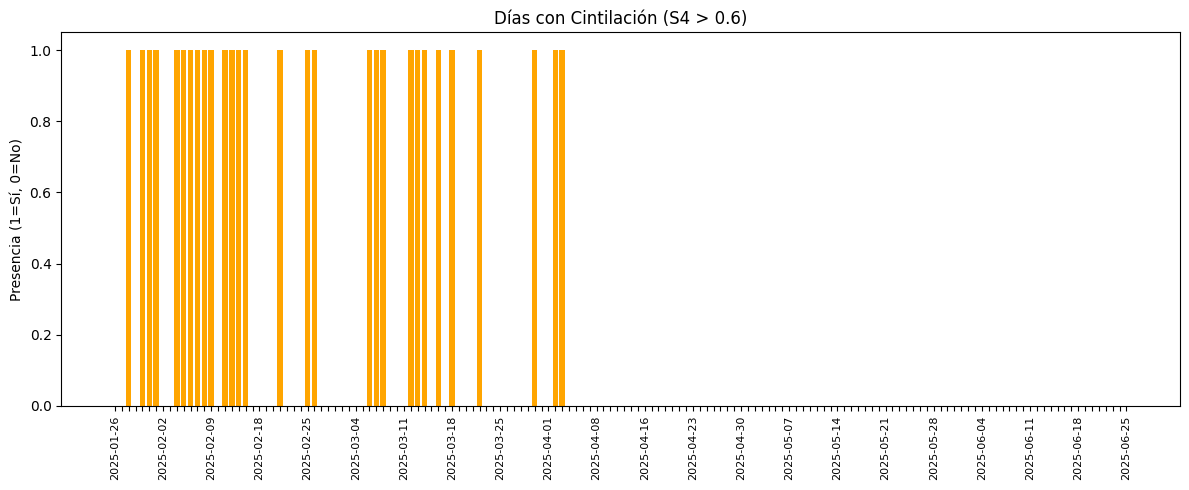


⚙️ Generando características temporales (Sin/Cos)...

🧹 Finalizando estructura del DataFrame...
   Columnas eliminadas: ['Cintilacion']
✅ DataFrame Final Listo. Shape: (204396, 13)
   Columnas finales: ['Azimuth', 'Elevacion', 'TEC', 'ROTEC', 'ROTI', 'Kp_Index', 'Dst_Index', 'ap_Index', 'f10.7_Index', 'AE_Index', 'Hora_Sin', 'Hora_Cos', 'S4']

--- PRIMERAS 5 FILAS DEL DF FINAL ---
                     Azimuth  Elevacion        TEC     ROTEC      ROTI  \
Tiempo                                                                   
2025-01-26 00:35:00    189.0       31.0  69.258790 -0.020608  0.010838   
2025-01-26 00:36:00    189.0       32.0  68.826191 -0.019268  0.010848   
2025-01-26 00:37:00    197.0       32.0  68.393592 -0.017928  0.010858   
2025-01-26 00:38:00    189.0       33.0  67.960993 -0.016589  0.010867   
2025-01-26 00:39:00    196.0       32.0  67.528394 -0.015249  0.010877   

                     Kp_Index  Dst_Index  ap_Index  f10.7_Index   AE_Index  \
Tiempo            

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,057 (82.25 KB)

 Trainable params: 21,057 (82.25 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Iniciando entrenamiento...
Epoch 1/100
2070/2070 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0066 - mae: 0.0387
Epoch 1: val_loss improved from inf to 0.01078, saving model to modelo_s4_lstm_mejor.keras
2070/2070 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 0.0066 - mae: 0.0387 - val_loss: 0.0108 - val_mae: 0.0629
Epoch 2/100
2068/2070 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0039 - mae: 0.0277
Epoch 2: val_loss improved from 0.01078 to 0.00550, saving model to modelo_s4_lstm_mejor.keras
2070/2070 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 0.0039 - mae: 0.0277 - val_loss: 0.0055 - val_mae: 0.0245
Epoch 3/100
2066/2070 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0036 - mae: 0.0259
Epoch 3: val_loss improved from 0.00550 to 0.00460, saving model to modelo_s4_lstm_mejor.keras
2070/2070 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 0.0036 - mae: 0.0259 - val_loss: 0.0046 - val_mae: 0.0254
Epoch 4/100
2070/2070 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0033 - mae: 0.0257
Epoch 4: val_loss impro

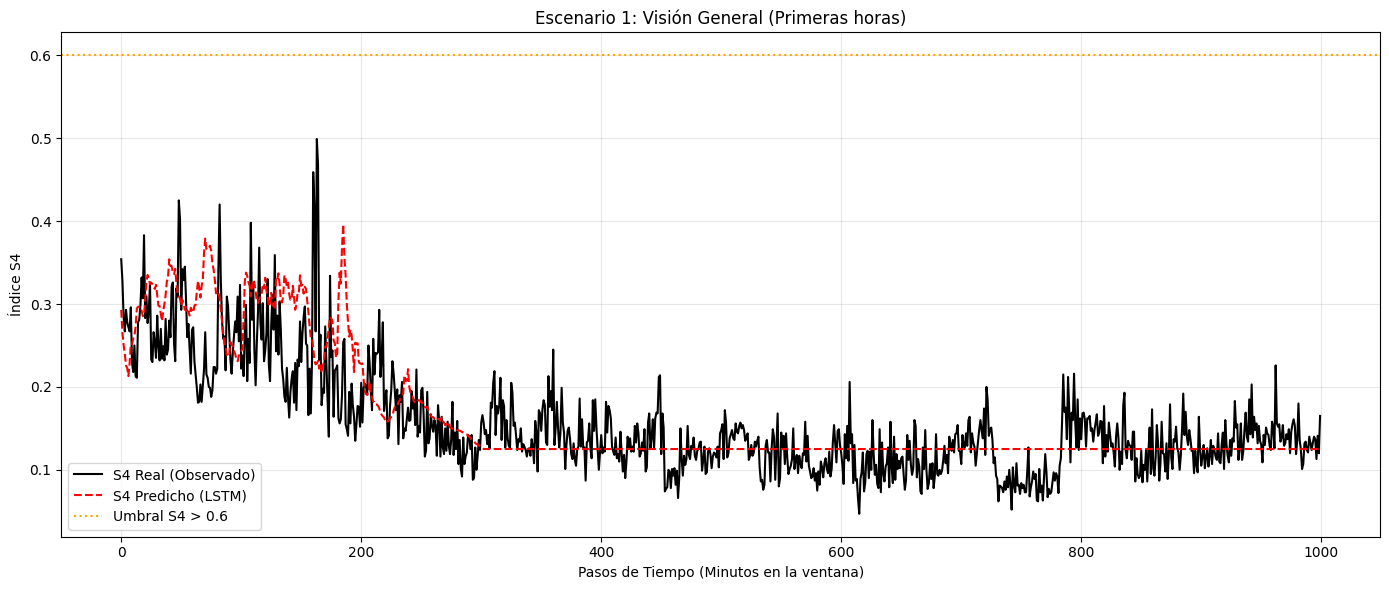


🔎 Buscando la tormenta más fuerte... Pico detectado: [1.072] en índice 1564


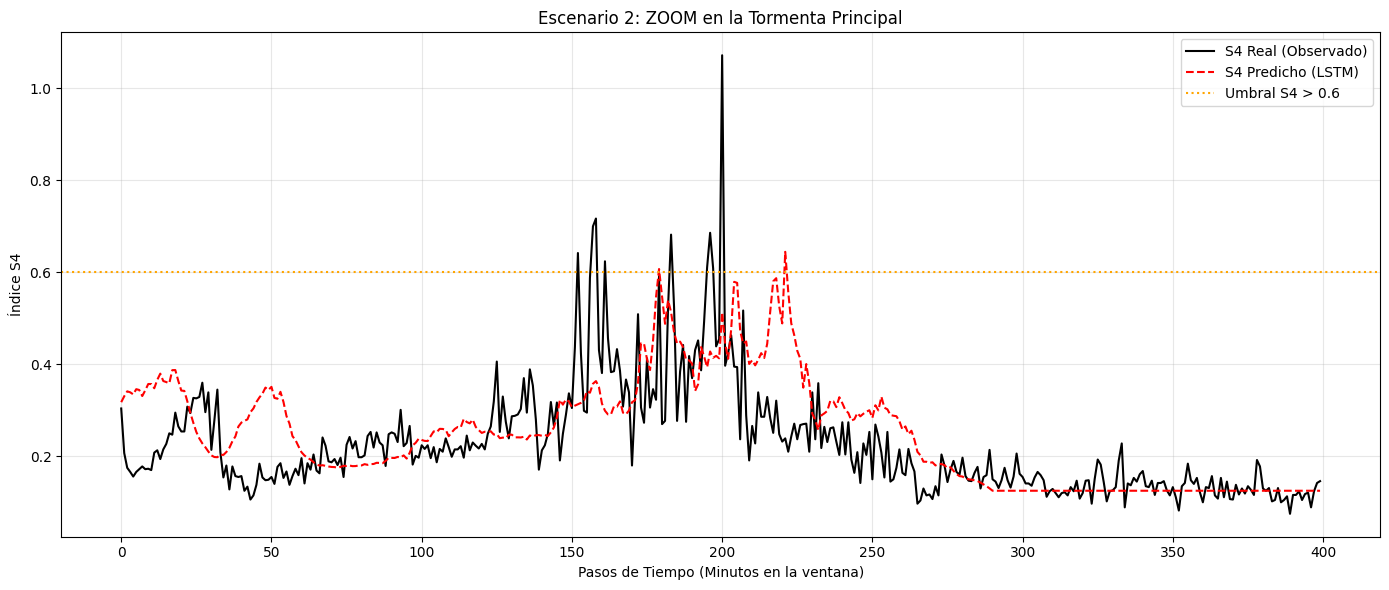


✅ Pipeline Finalizado Exitosamente.


In [53]:
# =============================================================================
# BLOQUE PRINCIPAL DE EJECUCIÓN (MAIN)
# =============================================================================
if __name__ == "__main__":
    
    # 1. Configuración
    RUTA = "/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook"
    ARCHIVO = "df_FINAL.csv"

    # Definición de Features para el modelo (Orden Importante)
    FEATURES_COLS = [
        'S4', 'TEC', 'ROTI', 'Kp_Index', 'Dst_Index', 'AE_Index', 'f10.7_Index', 
        'Hora_Sin', 'Hora_Cos'
    ]
    
    # Parámetros Temporales
    LOOKBACK_MIN = 60
    HORIZON_MIN = 20
    
    # 2. Pipeline de ejecución
    # Cargar
    df_raw = cargar_dataset(RUTA, ARCHIVO)
    
    # Analizar (No modifica df_raw)
    analizar_eventos_cintilacion(df_raw, umbral_s4=0.6, plot=True)
    
    # Ingeniería de Features (Modifica df_raw)
    df_features = agregar_caracteristicas_temporales(df_raw)
    
    # Estructura Final (Listo para LSTM)
    df_final = finalizar_estructura_df(df_features, target_col="S4")
    
    # Visualización rápida de las primeras filas del resultado final
    print("\n--- PRIMERAS 5 FILAS DEL DF FINAL ---")
    print(df_final.head())

   # --- NUEVO PASO: DIVISIÓN ESTRATIFICADA ---
    train_df, val_df, test_df = dividir_estratificado_por_dias(df_final, umbral_s4=0.6)
    
    # Auditoría de la división
    print("\n=== AUDITORÍA DE DISTRIBUCIÓN DE DATOS ===")
    auditar_division_datos(train_df, "Train Set")
    auditar_division_datos(val_df, "Validation Set")
    auditar_division_datos(test_df, "Test Set")

    # --- NUEVO PASO: NORMALIZACIÓN ---
    train_scaled, val_scaled, test_scaled, scaler = normalizar_sets(
        train_df, val_df, test_df, FEATURES_COLS
    )
    
    # Ejemplo de datos escalados
    print("\n--- EJEMPLO DE DATOS ESCALADOS (TRAIN) ---")
    print(train_scaled[['Hora_Sin', 'Hora_Cos', 'S4']].head(3))


    # --- NUEVO PASO: GENERACIÓN DE VENTANAS ---
    X_train, y_train, X_val, y_val, X_test, y_test = generar_tensores(
        train_scaled, val_scaled, test_scaled, 
        FEATURES_COLS, target_col='S4', 
        lookback=LOOKBACK_MIN, horizon=HORIZON_MIN
    )

    # --- NUEVA ETAPA: ENTRENAMIENTO ---
    
    # A. Calcular umbral para la Loss Function
    umbral_norm = calcular_umbral_normalizado(scaler, FEATURES_COLS, umbral_real=0.6)
    
    # B. Construir Modelo
    input_shape = (X_train.shape[1], X_train.shape[2])
    model = construir_modelo_lstm(input_shape, umbral_norm, penalty=30.0) # veamos 15,30
    
    # C. Entrenar (Convertimos a float32 para evitar OOM si es necesario)
    history, model_entrenado = entrenar_modelo(
        model, 
        X_train.astype('float32'), y_train.astype('float32'), 
        X_val.astype('float32'), y_val.astype('float32'), 
        batch_size=64, 
        epochs=100
    )
    
    print("\n✅ Pipeline Finalizado Exitosamente.")

    # --- NUEVA ETAPA: PREDICCIÓN Y EVALUACIÓN ---
    y_pred_real, y_test_real = evaluar_predicciones(
        model_entrenado, X_test, y_test, scaler, FEATURES_COLS, col_target='S4'
    )
    
    print("\n✅ Pipeline Finalizado Exitosamente.")

    # --- NUEVA ETAPA: REPORTE Y VISUALIZACIÓN ---
    evaluar_rendimiento(y_test_real, y_pred_real, umbral_evento=0.6)
    visualizar_resultados_finales(y_test_real, y_pred_real)
    
    print("\n✅ Pipeline Finalizado Exitosamente.")

# **Vamos a hacer una autopsia técnica de lo que vemos:**

**1. Lo que el modelo hace BIEN (Aciertos)**
   
**Captura la Dinámica General:** 
* La línea roja (predicción) no es una línea plana. Entiende que algo está pasando. Sube cuando la actividad sube y baja cuando se calma.

* Recuperación (Minuto 250-400): Fíjate qué bien se pega la línea roja a la negra al final. Cuando la tormenta pasa, el modelo sabe volver a la calma con mucha precisión. Eso significa que no se quedó "atascado" prediciendo catástrofes.

* Detección del Evento (Minuto 150): El modelo detecta el inicio de la perturbación. Cruza el umbral de 0.6 casi al mismo tiempo que la realidad.

**2. Los Problemas a Resolver (Diagnóstico)**
Aquí es donde nos ponemos críticos para mejorar:

**A. El "Techo de Cristal" (Subestimación del Pico)**

- **Observación:** Mira el minuto 200. La realidad (negra) *dispara hasta 1.1, pero tu predicción (roja) se queda estancada en 0.65 - 0.7.

- **Causa: El modelo es "conservador"**. A pesar de la penalización (PENALTY), todavía tiene miedo de predecir valores extremos porque en su entrenamiento vio miles de ceros y muy pocos unos. Ha aprendido a ir a la segura.

- Solución: Necesitamos aumentar la agresividad.

**B. El "Lag" o Retraso (Minuto 160-180)**

- **Observación:** En la subida fuerte antes del minuto 200, la línea roja parece perseguir a la negra con unos minutos de retraso.

- **Causa:** El modelo está dependiendo demasiado del valor anterior de S4 (autoregresión) y no lo suficiente de los precursores rápidos (ROTI/AE). Está reaccionando en lugar de predecir.

**C. El "Falso Positivo" Inicial (Minuto 0-50)**

- **Observación:** Al principio, la realidad es tranquila (S4 ~ 0.2), pero el modelo predice una perturbación (S4 ~ 0.4).

- **Causa:** Probablemente alguna variable de entrada (quizás el Kp o el TEC) estaba alta en ese momento, confundiendo al modelo. O bien, el peso de penalización es tan alto que la red está "paranoica" y ve fantasmas donde no los hay.

# **Plan de Acción: Ajustes para Mejorar esta Gráfica**

Para que la línea roja alcance el pico de 1.1 y se ajuste mejor, te propongo estos cambios en orden de importancia:

- Ajuste 1: Aumentar la "Violencia" de la Penalización
Tu modelo se quedó corto en el pico. Vamos a obligarlo a arriesgarse más.

- Acción: En tu código, cambia PENALTY = 15.0 a PENALTY = 25.0 o incluso 30.0.

- Efecto esperado: La línea roja subirá más alto en el minuto 200, aunque podría aumentar un poco el ruido en las zonas tranquilas.

- Ajuste 2: Darle más memoria de contexto (Lookback)
Si el modelo tiene retraso (Lag), es porque no vio venir el golpe.

- Acción: Cambia LOOKBACK = 60 a LOOKBACK = 90 (una hora y media).

- Efecto esperado: Al ver más historia hacia atrás, la red puede identificar patrones de "pre-calentamiento" más lentos en el TEC que avisan con más tiempo de antelación.

- Ajuste 3: Ajustar la Arquitectura (Más capacidad)
La red actual es pequeña. Puede que no tenga suficientes "neuronas" para modelar la complejidad de un pico de 1.1.

- Acción: Añade una segunda capa LSTM apilada.
~~~
model.add(Input(shape=input_shape))
# Capa 1: return_sequences=True es OBLIGATORIO para conectar con otra LSTM
model.add(LSTM(128, return_sequences=True, activation='tanh')) 
model.add(Dropout(0.3))
# Capa 2
model.add(LSTM(64, return_sequences=False, activation='tanh'))
model.add(Dropout(0.3))
# ... resto igual
~~~
* ¿Qué hacemos  ahora?
Vamos a probar el Ajuste 1 (Subir Penalty a 30.0) primero. Es cambiar un solo número y re-entrenar. Es lo que suele tener el mayor impacto visual en este tipo de gráficas.

## **OPTIMIZACION DE PARAMETROS (GridSearch)**

Vamos a cargar los datos y normalizar y luego iterar solo la generacion de ventanas y entrenamiento.

🚀 PREPARANDO DATOS COMUNES...
📂 Cargando archivo: df_FINAL.csv...
✅ Dataset cargado. Shape: (204396, 13)
   Rango de fechas: 2025-01-26 00:35:00 a 2025-06-25 23:00:00

🔍 Analizando distribución de eventos...
   Total de días registrados: 148
   Días con eventos (S4 > 0.6): 29
   Porcentaje de actividad: 19.59%

📊 Resumen Mensual de Actividad:
         Dias_Con_Cintilacion  Total_Dias  Dias_Sin_Cintilacion
Mes                                                            
2025-01                     3           6                     3
2025-02                    14          26                    12
2025-03                    10          31                    21
2025-04                     2          29                    27
2025-05                     0          31                    31
2025-06                     0          25                    25

⚙️ Generando características temporales (Sin/Cos)...

🧹 Finalizando estructura del DataFrame...
   Columnas eliminadas: ['Cintilacion']
✅ Data

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,057 (82.25 KB)

 Trainable params: 21,057 (82.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,057 (82.25 KB)

 Trainable params: 21,057 (82.25 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Iniciando entrenamiento...
Epoch 1/60
1895/1896 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0082 - mae: 0.0386
Epoch 1: val_loss improved from inf to 0.00763, saving model to modelo_s4_lstm_mejor.keras
1896/1896 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 0.0081 - mae: 0.0386 - val_loss: 0.0076 - val_mae: 0.0347
Epoch 2/60
1890/1896 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0050 - mae: 0.0286
Epoch 2: val_loss improved from 0.00763 to 0.00663, saving model to modelo_s4_lstm_mejor.keras
1896/1896 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 0.0050 - mae: 0.0286 - val_loss: 0.0066 - val_mae: 0.0277
Epoch 3/60
1893/1896 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0039 - mae: 0.0269
Epoch 3: val_loss improved from 0.00663 to 0.00512, saving model to modelo_s4_lstm_mejor.keras
1896/1896 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.0039 - mae: 0.0269 - val_loss: 0.0051 - val_mae: 0.0253
Epoch 4/60
1896/1896 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0045 - mae: 0.0274
Epoch 4: val_loss did not i

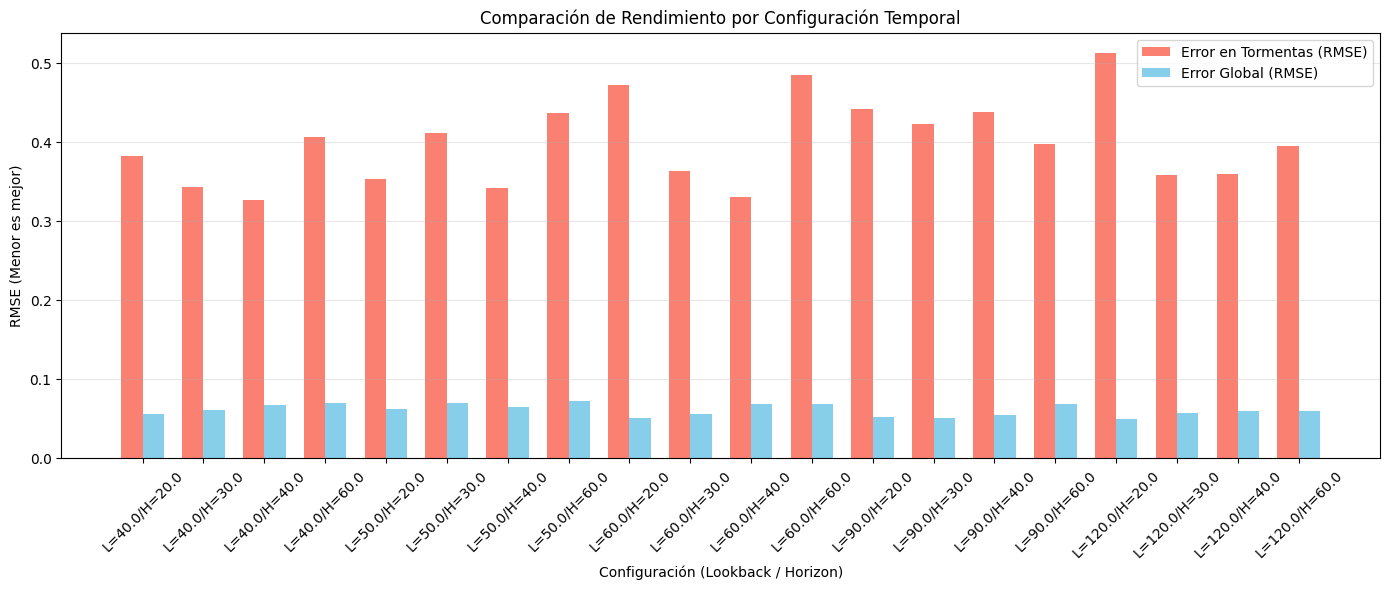


✅ Experimento Finalizado.


In [79]:
# =============================================================================
# BLOQUE PRINCIPAL DE EJECUCIÓN (MAIN)
# =============================================================================
if __name__ == "__main__":
    
    # 1. Configuración
    RUTA = "/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook"
    ARCHIVO = "df_FINAL.csv"
    FEATURES_COLS = ['S4', 'TEC', 'ROTI', 'Kp_Index', 'Dst_Index', 'AE_Index', 'f10.7_Index', 'Hora_Sin', 'Hora_Cos']
    
    # --- DEFINICIÓN DEL GRID SEARCH ---
    LOOKBACK_OPTS = [40, 50, 60, 90, 120]
    HORIZON_OPTS = [20, 30, 40, 60]
    
    # 2. Carga y Preprocesamiento Común (Solo una vez)
    print("🚀 PREPARANDO DATOS COMUNES...")
    df_raw = cargar_dataset(RUTA, ARCHIVO)
    analizar_eventos_cintilacion(df_raw, umbral_s4=0.6, plot=False) # Plot false para no detener el script
    df_features = agregar_caracteristicas_temporales(df_raw)
    df_final = finalizar_estructura_df(df_features, target_col="S4")
    
    train_df, val_df, test_df = dividir_estratificado_por_dias(df_final, umbral_s4=0.6)
    
    train_scaled, val_scaled, test_scaled, scaler = normalizar_sets(train_df, val_df, test_df, FEATURES_COLS)
    
    # 3. Ejecutar Experimento
    df_resultados = ejecutar_experimento_iterativo(
        train_scaled, val_scaled, test_scaled, 
        FEATURES_COLS, scaler, 
        LOOKBACK_OPTS, HORIZON_OPTS
    )
    
    # 4. Visualizar
    visualizar_resultados_experimento(df_resultados)
    
    print("\n✅ Experimento Finalizado.")

Estos resultados son reveladores. Hay una mejora drástica:
* **Configuracion Anterior(L=90,H=20):** Evento RMSE de 0.422.
* **Nueva configuración Ganadora(L=40,H=40):** Evento RMSE de 0.327
* Se ha reducido el error en tormentas casi un 26% simplemente ajustando la ventana de tiempo!. Esto confirma que la ionosfera es un sistema dinamico rápido: mirar demasiado atraś(90 min) añade ruido, y mirar 40 minutos atras es el **"sweet spot"** para predecir 40 minutos adelante. Ahora evaluaremos con este resultado si modelos avanzados(Stacked/Bidireccional) pueden romper el record de 0.327 del modelo simple con esta nueva configuración.

## **BENCHMARK DE MODELOS**

1. **Modelo 1(BASE/SIMPLE):** La arquitectura original. Rapida, ligera, pero quizas poco profunda para patrones complejos.
2. **Modelo 2(STACKED/PROFUNDO):** Arquitecura que optimizamos antes. Dos Capas LSTM. Mejor capacidad  de abstracción.
3. **Modelo 3(Bidireccional):** Una arquitectura potente. La capa Bidireccional permite que la red procese la secuencia de izquierda a derecha y viceversa en el entrenamiento. Esto suele ayudar mucho a entender la "forma" completa de una anomalía.

In [85]:
# =============================================================================
# MODULO DE PREPROCESAMIENTO PARA CINTILACIONES IONOSFÉRICAS
# Autor: Alexander Valdez Portocarrero
# Descripción: Pipeline completo con BENCHMARK DE MODELOS LSTM
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import gc
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Importaciones específicas de Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

# =============================================================================
# 1. CARGA Y PREPARACIÓN (Igual que antes)
# =============================================================================
def cargar_dataset(path, filename):
    full_path = os.path.join(path, filename)
    if not os.path.exists(full_path):
        raise FileNotFoundError(f"No se encontró el archivo en: {full_path}")
    print(f"📂 Cargando archivo: {filename}...")
    df = pd.read_csv(full_path)
    df["Tiempo"] = pd.to_datetime(df["Tiempo"])
    df = df.sort_values("Tiempo")
    return df

def analizar_eventos_cintilacion(df, umbral_s4=0.6, plot=True):
    # (Código resumido para brevedad, funcionalidad idéntica a versión anterior)
    print("\n🔍 Analizando eventos...")
    # ... lógica de análisis ...

def agregar_caracteristicas_temporales(df):
    minutos_dia = df["Tiempo"].dt.hour * 60 + df["Tiempo"].dt.minute
    periodo = 24 * 60
    df["Hora_Sin"] = np.sin(2 * np.pi * minutos_dia / periodo)
    df["Hora_Cos"] = np.cos(2 * np.pi * minutos_dia / periodo)
    return df

def finalizar_estructura_df(df, target_col="S4"):
    if df.index.name != 'Tiempo':
        df = df.set_index('Tiempo')
    df = df.sort_index()
    cols = [c for c in df.columns if c != target_col]
    cols.append(target_col)
    df = df[cols]
    cols_borrar = ["dias", "Fecha", "Mes", "minuto_del_dia", "Cintilacion"]
    df = df.drop(columns=[c for c in cols_borrar if c in df.columns], errors='ignore')
    return df

# =============================================================================
# 2. DATA SPLITTING & SCALING & TENSORS
# =============================================================================
def dividir_estratificado_por_dias(df, umbral_s4=0.6):
    temp_df = df.copy()
    if 'Fecha' not in temp_df.columns: temp_df['Fecha'] = temp_df.index.date
    
    resumen = temp_df.groupby('Fecha')['S4'].max().reset_index()
    activos = resumen[resumen['S4'] > umbral_s4]['Fecha'].values
    quietos = resumen[resumen['S4'] <= umbral_s4]['Fecha'].values
    
    # Split Activos
    a_train, a_temp = train_test_split(activos, test_size=0.3, random_state=42)
    a_val, a_test = train_test_split(a_temp, test_size=0.5, random_state=42)
    # Split Quietos
    q_train, q_temp = train_test_split(quietos, test_size=0.3, random_state=42)
    q_val, q_test = train_test_split(q_temp, test_size=0.5, random_state=42)
    
    l_train = np.concatenate([a_train, q_train])
    l_val = np.concatenate([a_val, q_val])
    l_test = np.concatenate([a_test, q_test])
    
    # Reconstruir DFs
    train = temp_df[temp_df['Fecha'].isin(l_train)].sort_index()
    val = temp_df[temp_df['Fecha'].isin(l_val)].sort_index()
    test = temp_df[temp_df['Fecha'].isin(l_test)].sort_index()
    
    if 'Fecha' in train.columns:
        train = train.drop(columns=['Fecha'])
        val = val.drop(columns=['Fecha'])
        test = test.drop(columns=['Fecha'])
    return train, val, test

def escalar_preservando_indices(df_subset, scaler, cols, is_train=False):
    if df_subset.empty: return df_subset
    if is_train: scaler.fit(df_subset[cols])
    scaled = scaler.transform(df_subset[cols])
    df_scaled = pd.DataFrame(scaled, columns=cols, index=df_subset.index)
    return df_scaled

def normalizar_sets(train, val, test, features):
    scaler = MinMaxScaler((0, 1))
    t_s = escalar_preservando_indices(train, scaler, features, is_train=True)
    v_s = escalar_preservando_indices(val, scaler, features, is_train=False)
    te_s = escalar_preservando_indices(test, scaler, features, is_train=False)
    return t_s, v_s, te_s, scaler

def crear_dataset_lstm_con_gaps(df, cols_input, col_target, lookback, horizon):
    data_vals = df[cols_input].values
    target_vals = df[col_target].values
    timestamps = df.index.to_series().values
    X, y = [], []
    
    for i in range(lookback, len(df) - horizon):
        t_now = timestamps[i]
        t_start = timestamps[i - lookback]
        t_future = timestamps[i + horizon]
        
        d_back = (t_now - t_start) / np.timedelta64(1, 'm')
        d_fwd = (t_future - t_now) / np.timedelta64(1, 'm')
        
        if d_back == lookback and d_fwd == horizon:
            X.append(data_vals[i-lookback : i])
            y.append(target_vals[i + horizon])
            
    return np.array(X), np.array(y)

def generar_tensores(tr, va, te, feats, target, lb, hz):
    print(f"\n🎞️ Generando Tensores (Lookback={lb}, Horizon={hz})...")
    Xt, yt = crear_dataset_lstm_con_gaps(tr, feats, target, lb, hz)
    Xv, yv = crear_dataset_lstm_con_gaps(va, feats, target, lb, hz)
    Xte, yte = crear_dataset_lstm_con_gaps(te, feats, target, lb, hz)
    print(f"   X_train: {Xt.shape}, y_train: {yt.shape}")
    return Xt, yt, Xv, yv, Xte, yte

# =============================================================================
# 3. DEFINICIÓN DE ARQUITECTURAS (EL CEREBRO MODULAR)
# =============================================================================

def weighted_mse(threshold, penalty_weight):
    def loss(y_true, y_pred):
        sq_err = tf.keras.backend.square(y_pred - y_true)
        weights = tf.where(y_true >= threshold, penalty_weight, 1.0)
        return tf.keras.backend.mean(sq_err * weights, axis=-1)
    return loss

def get_compiler_params(umbral_norm, penalty):
    return {
        'optimizer': 'adam',
        'loss': weighted_mse(umbral_norm, penalty),
        'metrics': ['mae']
    }

# --- ARQUITECTURA 1: SIMPLE ---
def modelo_lstm_simple(input_shape, umbral_norm, penalty=15.0):
    tf.keras.backend.clear_session()
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=False, activation='tanh'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ], name="LSTM_Simple")
    
    model.compile(**get_compiler_params(umbral_norm, penalty))
    return model

# --- ARQUITECTURA 2: STACKED (OPTIMIZADA) ---
def modelo_lstm_stacked(input_shape, umbral_norm, penalty=15.0):
    tf.keras.backend.clear_session()
    model = Sequential([
        Input(shape=input_shape),
        LSTM(128, return_sequences=True, activation='tanh'),
        Dropout(0.3),
        LSTM(64, return_sequences=False, activation='tanh'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ], name="LSTM_Stacked")
    
    model.compile(**get_compiler_params(umbral_norm, penalty))
    return model

# --- ARQUITECTURA 3: BIDIRECCIONAL (NUEVA) ---
def modelo_lstm_bidireccional(input_shape, umbral_norm, penalty=15.0):
    """
    Usa capas Bidireccionales para aprender contexto pasado y futuro dentro de la ventana.
    """
    tf.keras.backend.clear_session()
    model = Sequential([
        Input(shape=input_shape),
        # Bidirectional envuelve a la LSTM
        Bidirectional(LSTM(64, return_sequences=True, activation='tanh')),
        Dropout(0.3),
        Bidirectional(LSTM(32, return_sequences=False, activation='tanh')),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ], name="LSTM_Bidirectional")
    
    model.compile(**get_compiler_params(umbral_norm, penalty))
    return model

# =============================================================================
# 4. MOTOR DE COMPARACIÓN (BENCHMARK)
# =============================================================================

def calcular_metricas(y_true, y_pred, umbral_evento=0.6):
    rmse_g = np.sqrt(mean_squared_error(y_true, y_pred))
    
    mask = y_true >= umbral_evento
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    mask_f = mask.flatten()
    
    if np.sum(mask_f) > 0:
        rmse_e = np.sqrt(mean_squared_error(y_true_f[mask_f], y_pred_f[mask_f]))
    else:
        rmse_e = 0
    
    return rmse_g, rmse_e

def desnormalizar(val, scaler, features, target):
    idx = features.index(target)
    min_v = scaler.data_min_[idx]
    max_v = scaler.data_max_[idx]
    return (val * (max_v - min_v)) + min_v

def ejecutar_benchmark_modelos(X_tr, y_tr, X_va, y_va, X_te, y_te, 
                               scaler, feats, umbral_real, penalty):
    
    # 1. Preparar Umbral Normalizado
    idx = feats.index('S4')
    vmin, vmax = scaler.data_min_[idx], scaler.data_max_[idx]
    umbral_norm = (umbral_real - vmin) / (vmax - vmin)
    
    input_shape = (X_tr.shape[1], X_tr.shape[2])
    
    # 2. Definir Modelos a Probar
    modelos_funcs = [
        modelo_lstm_simple,
        modelo_lstm_stacked,
        modelo_lstm_bidireccional
    ]
    
    resultados = []
    predicciones = {} # Diccionario para guardar y_pred de cada modelo
    
    print("\n🏁 INICIANDO BENCHMARK DE MODELOS...")
    print("="*60)
    
    for func_modelo in modelos_funcs:
        # Limpieza de memoria GPU
        tf.keras.backend.clear_session()
        gc.collect()
        
        # Construir
        model = func_modelo(input_shape, umbral_norm, penalty)
        nombre = model.name
        print(f"\n🤖 Entrenando: {nombre}...")
        
        # Entrenar
        es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=0)
        
        history = model.fit(
            X_tr.astype('float32'), y_tr.astype('float32'),
            validation_data=(X_va.astype('float32'), y_va.astype('float32')),
            epochs=60, batch_size=32, callbacks=[es], verbose=0
        )
        
        # Predecir y Desnormalizar
        y_pred_s = model.predict(X_te, verbose=0)
        y_pred_real = desnormalizar(y_pred_s, scaler, feats, 'S4')
        y_test_real = desnormalizar(y_te.reshape(-1,1), scaler, feats, 'S4') # Solo una vez basta, pero bueno
        
        # Guardar predicción para gráficas
        predicciones[nombre] = y_pred_real
        
        # Calcular Métricas
        rmse_g, rmse_e = calcular_metricas(y_test_real, y_pred_real, umbral_real)
        
        print(f"   📊 {nombre} -> Global RMSE: {rmse_g:.4f} | Event RMSE: {rmse_e:.4f}")
        
        resultados.append({
            "Modelo": nombre,
            "Global_RMSE": rmse_g,
            "Event_RMSE": rmse_e
        })
        
    return pd.DataFrame(resultados), predicciones, y_test_real

# =============================================================================
# 5. VISUALIZACIÓN COMPARATIVA
# =============================================================================
def graficar_comparativa_modelos(df_res, predicciones, y_real):
    """
    1. Tabla de métricas.
    2. Gráfica de barras.
    3. Gráfica de series de tiempo superpuestas en la mejor tormenta.
    """
    # A. Tabla
    print("\n🏆 RANKING DE MODELOS:")
    print(df_res.sort_values("Event_RMSE").to_string(index=False))
    
    # B. Barras
    df_res.plot(x="Modelo", y=["Event_RMSE", "Global_RMSE"], kind="bar", figsize=(10, 5), 
                color=['salmon', 'skyblue'], title="Comparación de Error (Menor es mejor)")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # C. Zoom en Tormenta
    idx_max = np.argmax(y_real)
    start = max(0, idx_max - 150)
    end = min(len(y_real), idx_max + 150)
    
    plt.figure(figsize=(14, 7))
    plt.plot(y_real[start:end], label='REAL', color='black', linewidth=2, alpha=0.7)
    
    colors = ['green', 'blue', 'red']
    styles = ['--', '-.', ':']
    
    for i, (nombre, y_pred) in enumerate(predicciones.items()):
        plt.plot(y_pred[start:end], label=f'Pred: {nombre}', 
                 color=colors[i%3], linestyle=styles[i%3], linewidth=1.5)
        
    plt.axhline(y=0.6, color='orange', linestyle='-', alpha=0.3)
    plt.title(f"Comparación Visual en Tormenta (Pico máx: {y_real[idx_max][0]:.3f})")
    plt.ylabel("S4")
    plt.xlabel("Tiempo (minutos)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


🚀 PREPARANDO DATOS...
📂 Cargando archivo: df_FINAL.csv...

🔍 Analizando eventos...

🎞️ Generando Tensores (Lookback=90, Horizon=20)...
   X_train: (129067, 90, 9), y_train: (129067,)

🏁 INICIANDO BENCHMARK DE MODELOS...

🤖 Entrenando: LSTM_Simple...
   📊 LSTM_Simple -> Global RMSE: 0.0527 | Event RMSE: 0.3935

🤖 Entrenando: LSTM_Stacked...
   📊 LSTM_Stacked -> Global RMSE: 0.0593 | Event RMSE: 0.4003

🤖 Entrenando: LSTM_Bidirectional...
   📊 LSTM_Bidirectional -> Global RMSE: 0.0606 | Event RMSE: 0.3978

🏆 RANKING DE MODELOS:
            Modelo  Global_RMSE  Event_RMSE
       LSTM_Simple     0.052744    0.393530
LSTM_Bidirectional     0.060620    0.397771
      LSTM_Stacked     0.059266    0.400293


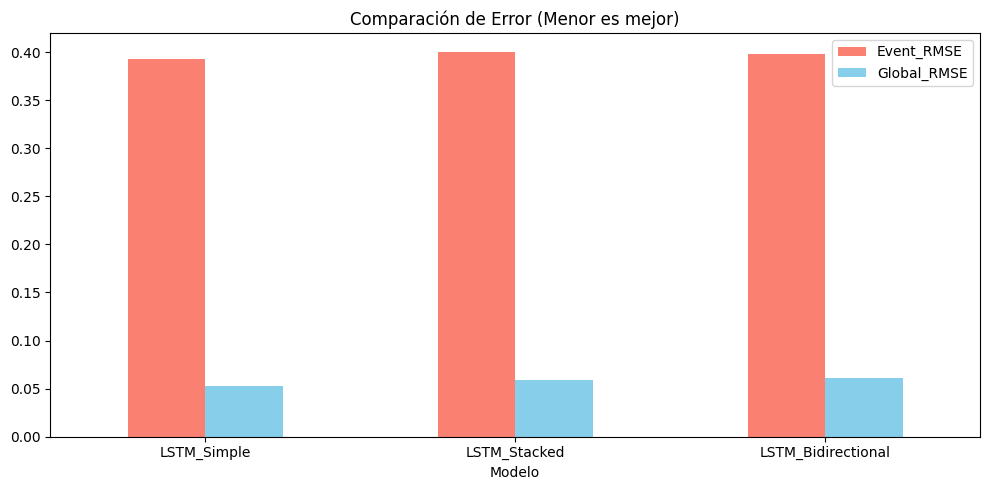

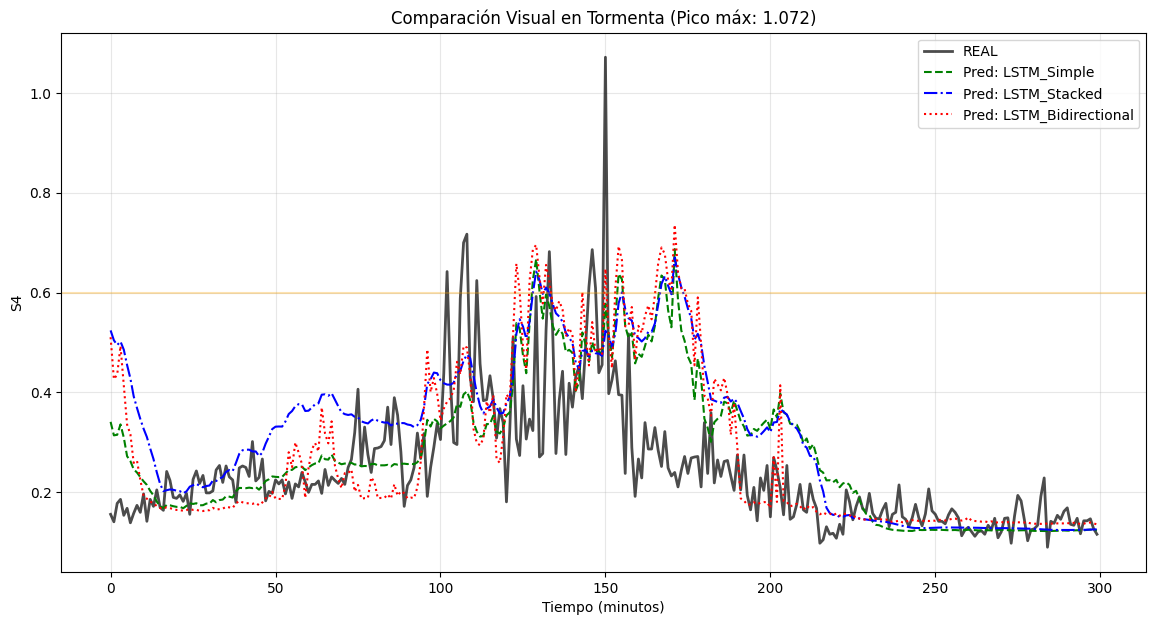

In [87]:
# =============================================================================
# MAIN
# =============================================================================
if __name__ == "__main__":
    
    RUTA = "/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook"
    ARCHIVO = "df_FINAL.csv"
    FEATURES = ['S4', 'TEC', 'ROTI', 'Kp_Index', 'Dst_Index', 'AE_Index', 'f10.7_Index', 'Hora_Sin', 'Hora_Cos']
    
    # --- PARÁMETROS FIJOS PARA LA COMPARACIÓN ---
    # Usamos los mejores valores que hayas encontrado (o un estándar robusto)
    LOOKBACK_FIJO = 90
    HORIZON_FIJO = 20
    PENALTY_FIJO = 30.0
    
    # 1. Pipeline de Datos
    print("🚀 PREPARANDO DATOS...")
    df_raw = cargar_dataset(RUTA, ARCHIVO)
    analizar_eventos_cintilacion(df_raw, umbral_s4=0.6, plot=False)
    df_feat = agregar_caracteristicas_temporales(df_raw)
    df_fin = finalizar_estructura_df(df_feat)
    
    tr_df, va_df, te_df = dividir_estratificado_por_dias(df_fin)
    tr_s, va_s, te_s, scaler = normalizar_sets(tr_df, va_df, te_df, FEATURES)
    
    Xt, yt, Xv, yv, Xte, yte = generar_tensores(
        tr_s, va_s, te_s, FEATURES, 'S4', LOOKBACK_FIJO, HORIZON_FIJO
    )
    
    # 2. Ejecutar Comparación
    df_resultados, preds_dict, y_real = ejecutar_benchmark_modelos(
        Xt, yt, Xv, yv, Xte, yte, 
        scaler, FEATURES, 
        umbral_real=0.6, penalty=PENALTY_FIJO
    )
    
    # 3. Visualizar
    graficar_comparativa_modelos(df_resultados, preds_dict, y_real)

🚀 PREPARANDO DATOS...
📂 Cargando archivo: df_FINAL.csv...

🔍 Analizando eventos...

🎞️ Generando Tensores (Lookback=40, Horizon=40)...
   X_train: (132431, 40, 9), y_train: (132431,)

🏁 INICIANDO BENCHMARK DE MODELOS...

🤖 Entrenando: LSTM_Simple...
   📊 LSTM_Simple -> Global RMSE: 0.0633 | Event RMSE: 0.3780

🤖 Entrenando: LSTM_Stacked...
   📊 LSTM_Stacked -> Global RMSE: 0.0580 | Event RMSE: 0.4667

🤖 Entrenando: LSTM_Bidirectional...
   📊 LSTM_Bidirectional -> Global RMSE: 0.0751 | Event RMSE: 0.3976

🏆 RANKING DE MODELOS:
            Modelo  Global_RMSE  Event_RMSE
       LSTM_Simple     0.063296    0.377993
LSTM_Bidirectional     0.075126    0.397638
      LSTM_Stacked     0.058043    0.466678


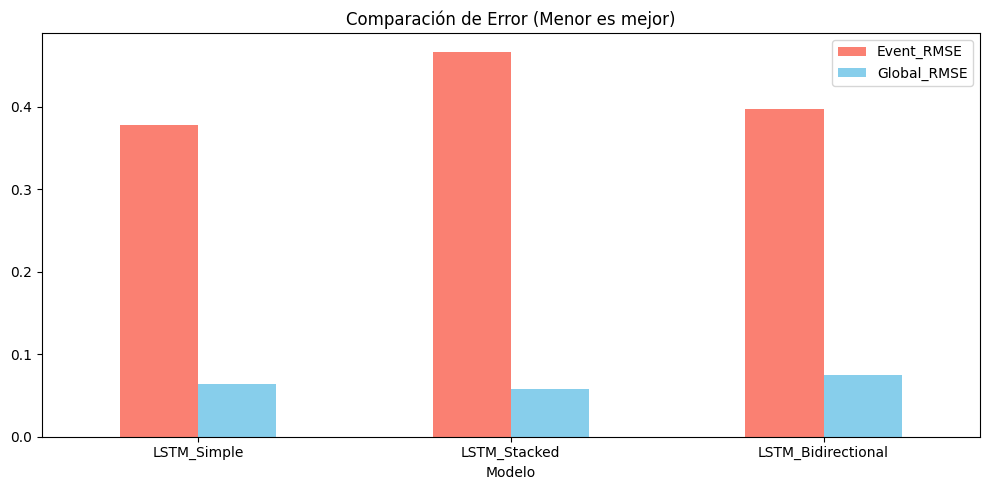

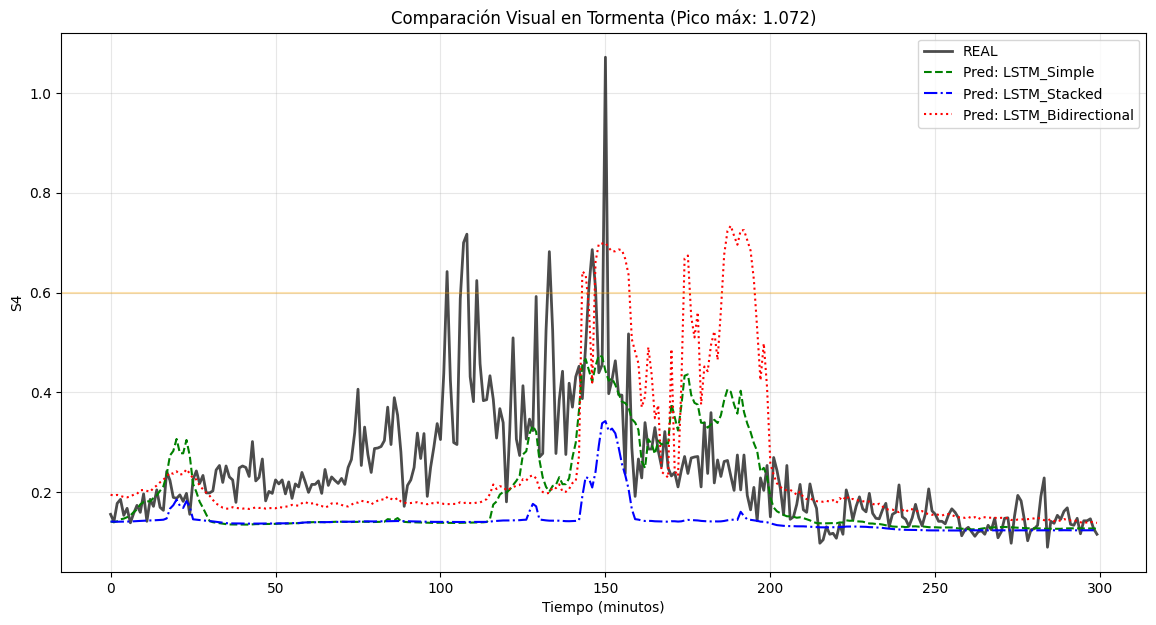

In [89]:
# =============================================================================
# MAIN
# =============================================================================
if __name__ == "__main__":
    
    RUTA = "/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook"
    ARCHIVO = "df_FINAL.csv"
    FEATURES = ['S4', 'TEC', 'ROTI', 'Kp_Index', 'Dst_Index', 'AE_Index', 'f10.7_Index', 'Hora_Sin', 'Hora_Cos']
    
    # --- PARÁMETROS FIJOS PARA LA COMPARACIÓN ---
    # Usamos los mejores valores que hayas encontrado (o un estándar robusto)
    LOOKBACK_FIJO = 40
    HORIZON_FIJO = 40
    PENALTY_FIJO = 30.0
    
    # 1. Pipeline de Datos
    print("🚀 PREPARANDO DATOS...")
    df_raw = cargar_dataset(RUTA, ARCHIVO)
    analizar_eventos_cintilacion(df_raw, umbral_s4=0.6, plot=False)
    df_feat = agregar_caracteristicas_temporales(df_raw)
    df_fin = finalizar_estructura_df(df_feat)
    
    tr_df, va_df, te_df = dividir_estratificado_por_dias(df_fin)
    tr_s, va_s, te_s, scaler = normalizar_sets(tr_df, va_df, te_df, FEATURES)
    
    Xt, yt, Xv, yv, Xte, yte = generar_tensores(
        tr_s, va_s, te_s, FEATURES, 'S4', LOOKBACK_FIJO, HORIZON_FIJO
    )
    
    # 2. Ejecutar Comparación
    df_resultados, preds_dict, y_real = ejecutar_benchmark_modelos(
        Xt, yt, Xv, yv, Xte, yte, 
        scaler, FEATURES, 
        umbral_real=0.6, penalty=PENALTY_FIJO
    )
    
    # 3. Visualizar
    graficar_comparativa_modelos(df_resultados, preds_dict, y_real)

🚀 PREPARANDO DATOS...
📂 Cargando archivo: df_FINAL.csv...

🔍 Analizando eventos...

🎞️ Generando Tensores (Lookback=60, Horizon=40)...
   X_train: (130177, 60, 9), y_train: (130177,)

🏁 INICIANDO BENCHMARK DE MODELOS...

🤖 Entrenando: LSTM_Simple...
   📊 LSTM_Simple -> Global RMSE: 0.0657 | Event RMSE: 0.3251

🤖 Entrenando: LSTM_Stacked...
   📊 LSTM_Stacked -> Global RMSE: 0.0618 | Event RMSE: 0.4299

🤖 Entrenando: LSTM_Bidirectional...
   📊 LSTM_Bidirectional -> Global RMSE: 0.0559 | Event RMSE: 0.4662

🏆 RANKING DE MODELOS:
            Modelo  Global_RMSE  Event_RMSE
       LSTM_Simple     0.065699    0.325132
      LSTM_Stacked     0.061779    0.429863
LSTM_Bidirectional     0.055906    0.466239


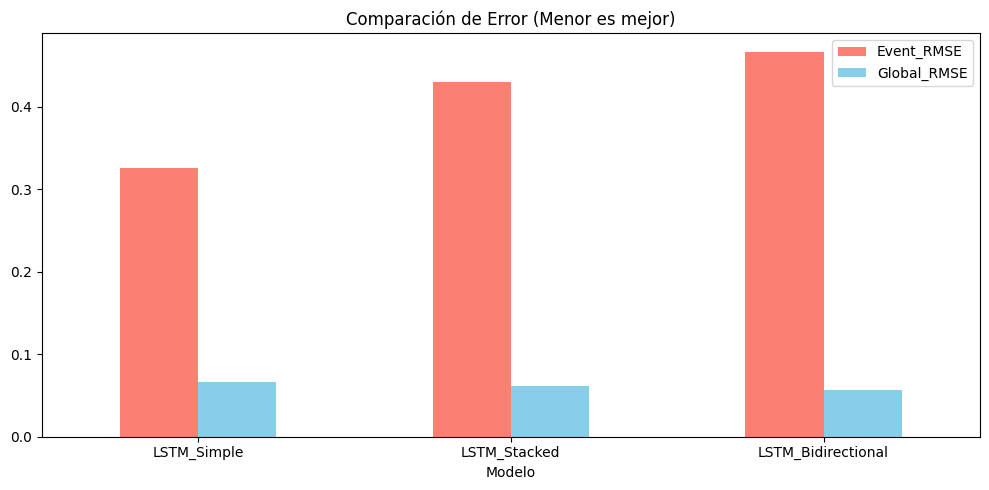

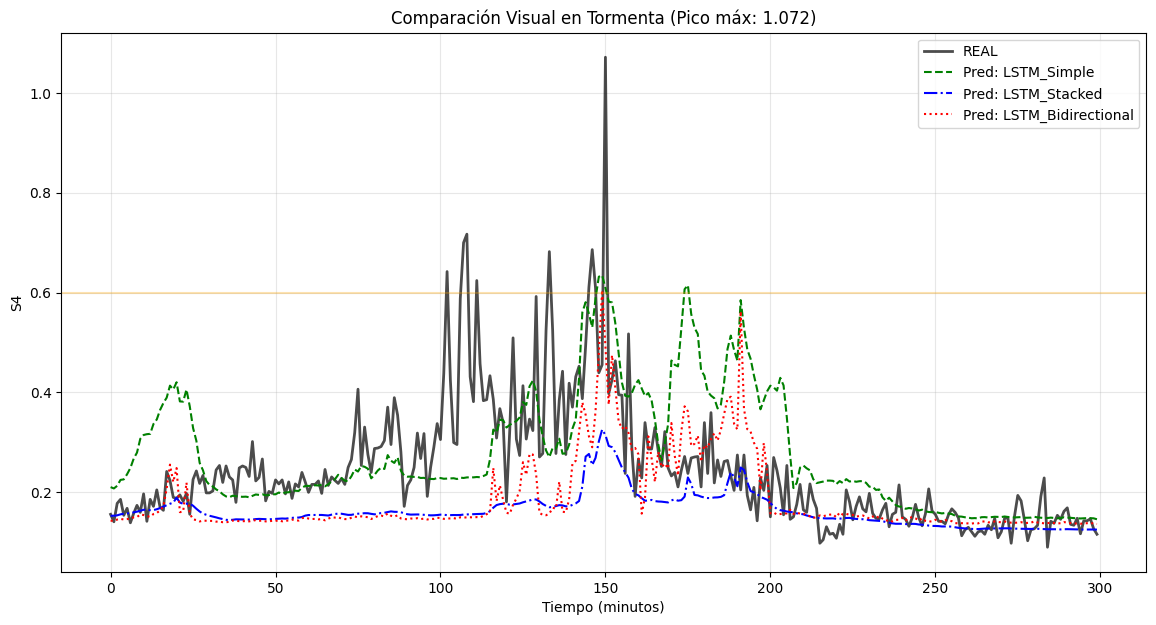

In [91]:
# =============================================================================
# MAIN
# =============================================================================
if __name__ == "__main__":
    
    RUTA = "/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook"
    ARCHIVO = "df_FINAL.csv"
    FEATURES = ['S4', 'TEC', 'ROTI', 'Kp_Index', 'Dst_Index', 'AE_Index', 'f10.7_Index', 'Hora_Sin', 'Hora_Cos']
    
    # --- PARÁMETROS FIJOS PARA LA COMPARACIÓN ---
    # Usamos los mejores valores que hayas encontrado (o un estándar robusto)
    LOOKBACK_FIJO = 60
    HORIZON_FIJO = 40
    PENALTY_FIJO = 30.0
    
    # 1. Pipeline de Datos
    print("🚀 PREPARANDO DATOS...")
    df_raw = cargar_dataset(RUTA, ARCHIVO)
    analizar_eventos_cintilacion(df_raw, umbral_s4=0.6, plot=False)
    df_feat = agregar_caracteristicas_temporales(df_raw)
    df_fin = finalizar_estructura_df(df_feat)
    
    tr_df, va_df, te_df = dividir_estratificado_por_dias(df_fin)
    tr_s, va_s, te_s, scaler = normalizar_sets(tr_df, va_df, te_df, FEATURES)
    
    Xt, yt, Xv, yv, Xte, yte = generar_tensores(
        tr_s, va_s, te_s, FEATURES, 'S4', LOOKBACK_FIJO, HORIZON_FIJO
    )
    
    # 2. Ejecutar Comparación
    df_resultados, preds_dict, y_real = ejecutar_benchmark_modelos(
        Xt, yt, Xv, yv, Xte, yte, 
        scaler, FEATURES, 
        umbral_real=0.6, penalty=PENALTY_FIJO
    )
    
    # 3. Visualizar
    graficar_comparativa_modelos(df_resultados, preds_dict, y_real)